# Demo: Generating Labels with LLMs

We have seen that BERTopic generates standard labels for the topics. These labels are based on the top words of each topic (based on the `c-TF-IDF` computation):

pattern: `{topic_id}_{topword1}_{topword2}_{topword3}_{topword4}`

example: _"2_basque_one_shall_think"_

We can now manually assign new label to the topics or we can also use Large Language Models to automatically generate descriptive labels for the topics. This notebook demonstrates different ways to do that.

1. Generate Labels Directly Through `BERTopic()`
2. Generate Labels for a Previously Generated Topic Model

## 0. Dataset

In this demonstration, the HSA sample generated in session 11 (`/11_wolff_bertopic_pipeline`) will be used. It consists of 1998 letters sampled from the full HSA dataset (`materials/datasets/hsa/letters_full.csv`) equally distributed across languages:

| language | count |
| --- | --- | 
| de | 333 | 
| fr | 333 | 
| it | 333 | 
| pt | 333 | 
| es | 333 | 
| en | 333 | 

The sample was embedded with the `paraphrase-multilingual-mpnet-base-v2` ([model card](https://huggingface.co/sentence-transformers/paraphrase-multilingual-mpnet-base-v2)) model and the results were added to the `csv` file.


| Column | Description | Example |
| --- | --- | --- |
| source_file | `xml` file name | hsa.letter.9937.xml |
| pid | persistent identifier of the letter | L.9937-6 |
| sender_id | project ID of the sender  | https://gams.uni-graz.at/o:hsa.persons#P.1560 |
| sender | sender name | Geibel (jr.) |
| receiver_id | project ID of the receiver | https://gams.uni-graz.at/o:hsa.persons#P.109 |
| receiver | receiver name  | Schuchardt |
| date  | date  | 1879-10-10 |
| text | letter text | Sie müßten (...) |
| language | text language (ISO 639) | de |
| keywords | manually assigned keywords | Universität Graz | 
| word_count | number of words | 34 |
| Document | letter text (as submitted to BERTopic) | Sie müßten (...) |
| Topic | topic ID | 6 |
| Name | topic label | 6_journal_revista_envío_jornal |
| Representation | top 10 words of the topic | ['journal', 'revista', 'envío', 'jornal', 'heft', 'compte', 'plus', 'informations', 'theils', 'leído'] | 
| Representative_Docs | top 3 most representative documents | ['J’ai reçu hier (...)', 'Je n’ecris pas du tout (...)', 'Dein Aufsatz über „Sprachursprung“ (...)'] 
| Top_n_words | top 10 words of the topic | journal - revista - envío - jornal - heft - compte - plus - informations - theils - leído |
| Probability | topic-document assignment probability | 0.6958119103637327 |
| Representative_document | most representative document for this topic? True/False  | False |

In [7]:
# import pandas: you only need to do this once in every script
import pandas as pd

# read the CSV file into a DataFrame
df = pd.read_csv("sample_data/hsa_sample_mpnet.csv")

# display the first 2 rows of the DataFrame
df.head(2)

,source_file,pid,sender_id,sender,receiver_id,receiver,date,text,language,keywords,word_count,Document,Topic,Name,Representation,Representative_Docs,Top_n_words,Probability,Representative_document
0,hsa.letter.9937.xml,L.9937-6,https://gams.uni-graz.at/o:hsa.persons#P.1560,Geibel (jr.),https://gams.uni-graz.at/o:hsa.persons#P.109,Schuchardt,1879-10-10,Sie müßten das leicht von jedem älteren Colleg...,de,Universität Graz,34,Sie müßten das leicht von jedem älteren Colleg...,6,6_journal_revista_envío_jornal,"['journal', 'revista', 'envío', 'jornal', 'hef...",['J’ai reçu hier votre estimée du 5 courant et...,journal - revista - envío - jornal - heft - co...,0.695812,False
1,hsa.letter.2512.xml,L.2512-2,https://gams.uni-graz.at/o:hsa.persons#P.1451,Erber,https://gams.uni-graz.at/o:hsa.persons#P.109,Schuchardt,1883-01-20,"Ich bin auch bereit, allen Ihren gütigsten Auf...",de,Sprachkontaktphänomene; Soziolinguistik; Sprac...,24,"Ich bin auch bereit, allen Ihren gütigsten Auf...",0,0_letter_carta_ex_sempre,"['letter', 'carta', 'ex', 'sempre', 'didl', 'r...",['Nous allons bientôt inviter nos collègues de...,letter - carta - ex - sempre - didl - reçu - r...,1.000000,False


The imported dataset already had a topic model fit to it. However, for some tasks in this demonstration, we will need to refit it. So we will run some additional processeing on the dataframe first. 

In [56]:
# extract the text column from the DataFrame as a list of documents
documents = df['text'].to_list()

To fit the models in the next section, we will pass a multilingual list of stop words imported from `nltk` (as we did in exercise `02_swapping-embeddings`).

In [27]:
import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer

# set the languages for which to gather stopwords
languages = ['german', 'french', 'italian', 'portuguese', 'spanish', 'english']

# create an empty set to hold all multilingual stopwords
multilingual_stopwords = set()

# gather stopwords for each language and add them to the multilingual set
for lang in languages:
    multilingual_stopwords.update(stopwords.words(lang))

# create vectorizer_model with that stopword list
multi_vectorizer = CountVectorizer(stop_words=list(multilingual_stopwords))


[nltk_data] Downloading package stopwords to C:\Users\alvares-
[nltk_data]     freire\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## 1. Generate Labels Directly Through `BERTopic()`

One of `BERTopic()`s modules is the Representation Models layer (see the [documentation](https://maartengr.github.io/BERTopic/getting_started/representation/representation.html)). It is possible to fine-tune the standard representations generated by `BERTopic()` by chaining, for example, a Large Language Model for the generation of labels for the topics.

This section will look at two possibilities for this:

1.1. Using an OpenAI model

1.2. Using a local model with Ollama

### 1.1. Using an OpenAI model

Here we chain an OpenAI chat model into BERTopic's `representation_model` parameter so that, instead of the default keyword-based names, each topic gets a short, descriptive label generated by an LLM.

For that we use an `openai.OpenAI` client with an API key. A **client** here is a small Python object that handles the details of talking to a remote service: authentication, formatting the request correctly, sending it over the network, and parsing the response you get back. An API (Application Programming Interface) is the defined set of requests a service accepts and the responses it returns: the exchange between your code and the service is limited to that request-response pair, so no other internal information passes between the two sides.

The steps are:
1. Instantiate an `openai.OpenAI` client with an API key.
2. Define a `prompt` template with two placeholders that BERTopic fills in automatically for each topic: `[KEYWORDS]` (the topic's top keywords) and `[DOCUMENTS]` (the sample of representative documents).
3. Now we instantiate BERTopic's OpenAI object  `bertopic.representation.OpenAI` and pass our configurations: the client we created before (responsible for the exchange with OpenAI's servers), the model we want to use (the `gpt-3.5-turbo`), and our prompt template.
4. Fit `BERTopic()` as usual, passing the OpenAI wrapper as `representation_model`. BERTopic will call the OpenAI client once per topic during fitting. 

After `fit_transform`, the `Name` column returned by `get_topic_info()` no longer shows raw keywords: it shows the label the LLM generated for each topic. Note this call sends topic keywords and documents to OpenAI's API and incurs API costs per topic.

**A note on `UMAP`**

BERTopic performs dimensionality reduction by default using UMAP (Uniform Manifold Approximation and Projection). Here, instead of letting BERTopic create its own UMAP instance internally with default settings, we build one ourselves and pass it into `BERTopic(umap_model=umap_model, ...)`:

```python
  umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric="cosine", random_state=0)
```

We do this because UMAP's fitting procedure is stochastic. Left to its own defaults, each run places the same documents slightly differently in the reduced space, which changes which documents end up grouped together and produces different topics from one run to the next, even on identical data. Fixing `random_state=0` (or 42 as we have seen before) removes that randomness.

This notebook runs BERTopic twice on the same documents: once labeling topics with OpenAI (1.1), once labeling topics with a local Ollama model (1.2). Building the UMAP object once and passing that same seeded object into both `BERTopic()` calls guarantees both runs reduce and cluster the documents identically. The only thing that differs between the two runs afterward is which model generated the topic label text, which is what makes the two Name columns directly comparable.

In [ ]:
# import the libraries (just once per script)
from bertopic.representation import OpenAI
from bertopic import BERTopic
import openai
from umap import UMAP

# setup the OpenAI client by providing the API key
client = openai.OpenAI(api_key="sk-...") # *** YOUR OPENAI API KEY HERE ***

# define the prompt for generating topic labels
prompt = "These documents share these keywords: [KEYWORDS]\n\nDocuments:\n[DOCUMENTS]\n\nGive this topic a short, human-readable label in the format: topic: <label>"

# define the settings of the OpenAI call
openai_model = OpenAI(client, model="gpt-3.5-turbo", chat=True, prompt=prompt)

# create and fit the BERTopic model with the OpenAI representation model
custom_umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric="cosine", random_state=0)

topic_model = BERTopic(verbose=True, 
                       language="multilingual", 
                       umap_model=custom_umap_model, 
                       vectorizer_model=multi_vectorizer, 
                       representation_model=[openai_model])

topics, probs = topic_model.fit_transform(documents)

topic_model.get_topic_info()  # the Name column now holds OpenAI's generated labels

2026-09-25 13:36:11,911 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 63/63 [00:26<00:00,  2.34it/s]
2026-09-25 13:36:45,891 - BERTopic - Embedding - Completed ✓
2026-09-25 13:36:45,892 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-09-25 13:36:53,727 - BERTopic - Dimensionality - Completed ✓
2026-09-25 13:36:53,728 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-09-25 13:36:53,795 - BERTopic - Cluster - Completed ✓
2026-09-25 13:36:53,798 - BERTopic - Representation - Fine-tuning topics using representation models.
100%|██████████| 32/32 [00:45<00:00,  1.41s/it]
2026-09-25 13:37:39,197 - BERTopic - Representation - Completed ✓


,Topic,Count,Name,Representation,Representative_Docs
0,-1,1051,-1_Basque language and literature,[Basque language and literature],[I was much pleased to find a letter from you ...
1,0,90,0_Portuguese language variations in different ...,[Portuguese language variations in different r...,[Now it has happened to myself to visit old fr...
2,1,82,1_Basque language and literature research,[Basque language and literature research],[thanks for your Gothic or Gotha-ic postcard j...
3,2,55,2_Travel experiences and correspondence in Europe,[Travel experiences and correspondence in Europe],[In Calabria si trovano varie specie di trotto...
4,3,50,3_Basque language and etymology,[Basque language and etymology],"[I await your answer about baita, and pitilin ..."
5,4,47,4_Multilingual and Dialectal Literature in Ita...,[Multilingual and Dialectal Literature in Ital...,[Denn in Halle hatt‘ ich ja gar nichts für Ihr...
6,5,42,5_Language and Communication,[Language and Communication],"[In tâ bai, ou bâ - Eu vou, ou irei, Eu vou-me..."
7,6,41,6_Health and Well-being,[Health and Well-being],"[dalari può: ha molti amici, e, tra questi, ce..."
8,7,41,7_Linguistics and Literature Exchange,[Linguistics and Literature Exchange],[io ho messo tanto tempo a rispondere alla vs ...
9,8,40,8_Fishing nets and boats in Sicily,[Fishing nets and boats in Sicily],[Detta rete calasi allo sgraro cioè non perpen...


In [ ]:
# get information about the documents
df_gpt = topic_model.get_document_info(documents)
df_gpt =  df_gpt.rename(columns={"Name": "GPT_Name"})

### 1.2. Using a local model with Ollama

This repeats the exact same labeling process as 1.1, but swaps the paid OpenAI API for a model running locally through [Ollama](https://ollama.com/), useful when you would rather not send data to an external API, or want to avoid per-call costs.

[Ollama](https://ollama.com/) is a tool that downloads and runs open-weight LLMs (such as Llama 3.2) directly on your own machine. It starts a local background server that you send requests to, much like a cloud API, except the model runs entirely on your own hardware instead of a remote provider's.

Because Ollama uses an OpenAI-compatible endpoint, BERTopic's `OpenAI` representation wrapper can be reused unchanged. Ollama's local server, therefore, accepts requests formatted exactly the way OpenAI's API expects them, and returns responses in that same shape, so any code written against OpenAI's client library works against Ollama with no changes beyond pointing it at a different address. In practice, only the client's `base_url` changes here, to `http://localhost:11434/v1` instead of OpenAI's servers. The client still requires an `api_key` argument, but Ollama ignores its value, so any placeholder string works.

Two things differ from the setup in 1.1:
- **Prerequisites**: you need to install ollama locally ([quickstart guide](https://docs.ollama.com/quickstart))the Ollama server must be running locally and the target model must already be pulled. You might need to run `ollama pull llama3.2` if you haven't already pulled the model before.
- **`doc_length` / `tokenizer`**: local models like `llama3.2` typically have a much smaller context window than `gpt-3.5-turbo`, so the representative documents are truncated to 100 whitespace-tokenized words before being inserted into the prompt. Otherwise, long documents could silently overflow the context window and get cut off mid-prompt.

The same `prompt`, seeded `UMAP`, and `documents` from 1.1 are reused here, so the resulting topic clusters are identical between the two runs. Only the generated labels (and the model used to produce them) differ, which is what makes the two `Name` columns directly comparable.

In [28]:
# point the OpenAI client at the local Ollama server
ollama_client = openai.OpenAI(base_url="http://localhost:11434/v1", api_key="ollama")

# same settings as the OpenAI call, with a local model name
ollama_model = OpenAI(
    ollama_client,
    model="llama3.2",
    chat=True,
    prompt=prompt,
    doc_length=100,         # doc_length/tokenizer cut each representative document to 100 words
    tokenizer="whitespace",
)

# same seeded UMAP, so the clustering is identical to the OpenAI run; only the labels differ
topic_model_ollama = BERTopic(
    verbose=True,
    language="multilingual",
    umap_model=custom_umap_model,
    vectorizer_model=multi_vectorizer,
    representation_model=[ollama_model],
)
topics_ollama, probs_ollama = topic_model_ollama.fit_transform(documents)

topic_model_ollama.get_topic_info()  # the Name column now holds the local model's generated labels

2026-09-28 13:53:25,815 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 63/63 [00:20<00:00,  3.03it/s]
2026-09-28 13:53:52,792 - BERTopic - Embedding - Completed ✓
2026-09-28 13:53:52,793 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-09-28 13:53:57,854 - BERTopic - Dimensionality - Completed ✓
2026-09-28 13:53:57,855 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-09-28 13:53:57,907 - BERTopic - Cluster - Completed ✓
2026-09-28 13:53:57,916 - BERTopic - Representation - Fine-tuning topics using representation models.
100%|██████████| 32/32 [02:52<00:00,  5.39s/it]
2026-09-28 13:56:50,624 - BERTopic - Representation - Completed ✓


,Topic,Count,Name,Representation,Representative_Docs
0,-1,1051,-1_Basque Language and Culture: Correspondence...,[Basque Language and Culture: Correspondence a...,[I was much pleased to find a letter from you ...
1,0,90,0_**topic:** Linguistic Evolution of Indian-Eu...,[**topic:** Linguistic Evolution of Indian-Eur...,[Now it has happened to myself to visit old fr...
2,1,82,1_linguistic publication discussion - academy ...,[linguistic publication discussion - academy e...,[thanks for your Gothic or Gotha-ic postcard j...
3,2,55,"2_Roma/Italia: Travel and Work Experiences, in...","[Roma/Italia: Travel and Work Experiences, inc...",[In Calabria si trovano varie specie di trotto...
4,3,50,3_Language Comparison and Etymology Discussions,[Language Comparison and Etymology Discussions],"[I await your answer about baita, and pitilin ..."
5,4,47,4_Medieval and Renaissance Literature of Itali...,[Medieval and Renaissance Literature of Italia...,[Denn in Halle hatt‘ ich ja gar nichts für Ihr...
6,5,42,5_I cannot create content that promotes or glo...,[I cannot create content that promotes or glor...,"[In tâ bai, ou bâ - Eu vou, ou irei, Eu vou-me..."
7,6,41,6_Health Concerns and Family Matters,[Health Concerns and Family Matters],"[dalari può: ha molti amici, e, tra questi, ce..."
8,7,41,7_Oscar von Miller: Correspondence with The Ac...,[Oscar von Miller: Correspondence with The Aca...,[io ho messo tanto tempo a rispondere alla vs ...
9,8,40,8_Ancient Tonnara Architecture and Construction,[Ancient Tonnara Architecture and Construction],[Detta rete calasi allo sgraro cioè non perpen...


In [ ]:
# get information about the documents
df_ollama = topic_model_ollama.get_document_info(documents)
df_ollama =  df_ollama.rename(columns={"Name": "Ollama_Name"})

### Comparing the OpenAI and Ollama labels

Since both `topic_model` and `topic_model_ollama` were fit on the same documents using the same fitted UMAP model, the two  runs group documents into topics identically; only the label text differs between them, because that part comes from a separate step where each model reads the topic's documents and writes its own wording. The code below merges `df_gpt` and `df_ollama` into one table so the two sets of labels can be compared side by side for the same topic.

Before merging, we check that the two tables really do describe the same documents in the same order, since the merge below relies on that to line up rows correctly. `pd.merge` then joins the tables on their shared index and, because both tables share several column names (Topic, Probability, and so on), appends _GPT/_Ollama suffixes to tell the two versions of each column apart.

Several of those columns are expected to be identical between the two versions rather than genuinely different: Topic, Probability, Representative_document, and Representative_Docs all come from the clustering step, which happens before either LLM is ever called, so they should not depend on which model generated the label. The loop below checks this assumption explicitly for each column (rather than just assuming it), and once confirmed, keeps a single copy instead of two identical ones.

After that cleanup, the columns are reordered so the shared, non-comparison columns come first, followed by the two models' generated names and representations. The final line then drops Representation_GPT/Representation_Ollama as well, leaving a clean table focused only on GPT_Name and Ollama_Name.

In [55]:
# merge the 2 tables to compare the labels
assert (df_gpt["Document"].values == df_ollama["Document"].values).all()

df_merged = pd.merge(df_gpt, df_ollama, left_index=True, right_index=True, suffixes=("_GPT", "_Ollama"))

# these columns are identical between the two runs by construction: same documents, same
# seeded UMAP + vectorizer, so identical clustering. Verify that, then keep a single copy of each
shared_columns = ["Document", "Topic", "Probability", "Representative_document", "Representative_Docs"]
for col in shared_columns:
    gpt_col, ollama_col = f"{col}_GPT", f"{col}_Ollama"
    assert (df_merged[gpt_col] == df_merged[ollama_col]).all(), f"{col} differs between the two tables"
    df_merged = df_merged.drop(columns=[ollama_col]).rename(columns={gpt_col: col})

# Top_n_words duplicates Representation (same text, minus the list brackets), so drop it
df_merged = df_merged.drop(columns=["Top_n_words_GPT", "Top_n_words_Ollama"])

# shared columns first, then the actual GPT vs. Ollama comparison
df_merged = df_merged[shared_columns + ["GPT_Name", "Ollama_Name", "Representation_GPT", "Representation_Ollama"]]

df_merged.drop(columns=["Representation_GPT", "Representation_Ollama"], inplace=True)
df_merged.to_csv("merged_topic_model_document_info.csv", index=False)
df_merged.head()

,Document,Topic,Probability,Representative_document,Representative_Docs,GPT_Name,Ollama_Name
0,Sie müßten das leicht von jedem älteren Colleg...,30,1.000000,False,"['Je vous remercie vivement de votre lettre, e...",30_European Academic Correspondence and Inform...,30_European Academic Correspondence and Inform...
1,"Ich bin auch bereit, allen Ihren gütigsten Auf...",16,0.799711,False,['Eccole le affezioni delle mie creature; la m...,16_Romantic/Gender-based Request or Apology La...,16_Romantic/Gender-based Request or Apology La...
2,"S. M. der König Carlos hat, so viel ich weiss,...",-1,0.000000,False,['I was much pleased to find a letter from you...,-1_A Letter Exchange Between Academics and Sch...,-1_A Letter Exchange Between Academics and Sch...
3,Wenn es mir gelingt im Februar die Prüfung zu ...,-1,0.000000,False,['I was much pleased to find a letter from you...,-1_A Letter Exchange Between Academics and Sch...,-1_A Letter Exchange Between Academics and Sch...
4,"Einer meiner Studenten, ein Rätoromane, hat di...",3,1.000000,False,"['I await your answer about baita, and pitilin...",3_Language and Linguistics Study: Comparative ...,3_Language and Linguistics Study: Comparative ...


## 2. Generate Labels for a Previously Generated Topic Model

We're back to the same `df` from section 0. The difference is which topic model it reflects: in section 1 we fit two brand new topic models ourselves, but here we reuse the topic model that already came with the CSV, the one fit back in session 11. That model already grouped the documents into topics, so there's no `fit_transform()` in this section. We just read the topic, keywords, and representative documents already sitting in `df`, and use those to ask an LLM for a label.

In [67]:
df.head()

,source_file,pid,sender_id,sender,receiver_id,receiver,date,text,language,keywords,word_count,Document,Topic,Name,Representation,Representative_Docs,Top_n_words,Probability,Representative_document
0,hsa.letter.9937.xml,L.9937-6,https://gams.uni-graz.at/o:hsa.persons#P.1560,Geibel (jr.),https://gams.uni-graz.at/o:hsa.persons#P.109,Schuchardt,1879-10-10,Sie müßten das leicht von jedem älteren Colleg...,de,Universität Graz,34,Sie müßten das leicht von jedem älteren Colleg...,6,6_journal_revista_envío_jornal,"['journal', 'revista', 'envío', 'jornal', 'hef...",['J’ai reçu hier votre estimée du 5 courant et...,journal - revista - envío - jornal - heft - co...,0.695812,False
1,hsa.letter.2512.xml,L.2512-2,https://gams.uni-graz.at/o:hsa.persons#P.1451,Erber,https://gams.uni-graz.at/o:hsa.persons#P.109,Schuchardt,1883-01-20,"Ich bin auch bereit, allen Ihren gütigsten Auf...",de,Sprachkontaktphänomene; Soziolinguistik; Sprac...,24,"Ich bin auch bereit, allen Ihren gütigsten Auf...",0,0_letter_carta_ex_sempre,"['letter', 'carta', 'ex', 'sempre', 'didl', 'r...",['Nous allons bientôt inviter nos collègues de...,letter - carta - ex - sempre - didl - reçu - r...,1.000000,False
2,hsa.letter.4162.xml,L.4162-2,https://gams.uni-graz.at/o:hsa.persons#P.109,Schuchardt,https://gams.uni-graz.at/o:hsa.persons#P.2017,Leite de Vasconcelos,1901-05-23,"S. M. der König Carlos hat, so viel ich weiss,...",de,Fischereigeräte; Literaturbeschaffung; Revista...,66,"S. M. der König Carlos hat, so viel ich weiss,...",-1,-1_basque_one_mr_shall,"['basque', 'one', 'mr', 'shall', 'article', 'e...","[""thanks for your Gothic or Gotha-ic postcard ...",basque - one - mr - shall - article - etc - pl...,0.000000,False
3,hsa.letter.3315.xml,L.3315-3,https://gams.uni-graz.at/o:hsa.persons#P.2741,Sket,https://gams.uni-graz.at/o:hsa.persons#P.109,Schuchardt,1877-11-07,Wenn es mir gelingt im Februar die Prüfung zu ...,de,Biographisches; Dialekte; Diezstiftung; Lautph...,116,Wenn es mir gelingt im Februar die Prüfung zu ...,-1,-1_basque_one_mr_shall,"['basque', 'one', 'mr', 'shall', 'article', 'e...","[""thanks for your Gothic or Gotha-ic postcard ...",basque - one - mr - shall - article - etc - pl...,0.000000,False
4,hsa.letter.8585.xml,L.8585-5,https://gams.uni-graz.at/o:hsa.persons#P.1858,Jud,https://gams.uni-graz.at/o:hsa.persons#P.109,Schuchardt,1922-06-06,"Einer meiner Studenten, ein Rätoromane, hat di...",de,Sprach- und Sachatlas Italiens und der Südschw...,82,"Einer meiner Studenten, ein Rätoromane, hat di...",-1,-1_basque_one_mr_shall,"['basque', 'one', 'mr', 'shall', 'article', 'e...","[""thanks for your Gothic or Gotha-ic postcard ...",basque - one - mr - shall - article - etc - pl...,0.000000,False


In section 1, BERTopic filled in `[KEYWORDS]` and `[DOCUMENTS]` for us automatically. Nothing here is calling BERTopic, so we fill them in ourselves with an f-string instead: `{KEYWORDS}` and `{DOCUMENTS}` just get replaced by whatever those variables hold at that point in the loop below.

In [77]:
KEYWORDS = ""
DOCUMENTS = ""
prompt = f"These documents share these keywords: {KEYWORDS}\n\nDocuments:\n{DOCUMENTS}\n\nGive this topic a short, human-readable label in the format: topic: <label>"

Every document in `df` carries its topic's keywords and representative documents, repeated on every row that belongs to that topic. Looping over `df` directly would send the LLM the exact same prompt once per document, hundreds of times for a single topic. `topics_df` groups by `Topic` and keeps one row per topic, so we ask the LLM for a label exactly once per topic.

In [78]:
topics_df = df[["Topic", "Top_n_words","Representative_Docs"]].groupby("Topic").first()

We're not fitting BERTopic this time, so there's no need to go through its `OpenAI` wrapper like in 1.2. We can talk to Ollama directly with its own Python library instead: `ollama.generate(model=..., prompt=...)` sends one prompt and gets one response back, which is all we need here.

In [79]:
# import necessary libraries (just once per script)
import ollama

# create a container for the labels we generate
ollama_labels = {}

# iterate over each topic and generate a label using the LLM
for topic, row in topics_df.iterrows():
    KEYWORDS = row["Top_n_words"]
    DOCUMENTS = row["Representative_Docs"]
    label_prompt = f"The topic {topic} shares these keywords and has these 3 documents as the most representative: \nTop Keywords: {KEYWORDS}\nDocuments:\n{DOCUMENTS}\n\nGive this topic a short, human-readable label in the format: topic: <label>"
    # generate the label using the LLM
    response = ollama.generate(model="llama3.2", prompt=label_prompt)
    # store the generated label in the dictionary
    ollama_labels[topic] = response

`ollama.generate()` gives back more than just the label text. It returns an object that also records how long the call took and how many tokens were used. We'll use those numbers later to compare Llama and Gemma on speed. Run the cell below and look at one entry to see what's inside.

In [80]:
ollama_labels[1]

GenerateResponse(model='llama3.2', created_at='2026-09-28T14:59:42.2574033Z', done=True, done_reason='stop', total_duration=11525570400, load_duration=299092700, prompt_eval_count=1520, prompt_eval_duration=10429052000, eval_count=15, eval_duration=768966000, response='topic: Letters from a Glottologist with Interest in Language and Culture', thinking=None, context=[128006, 9125, 128007, 271, 38766, 1303, 33025, 2696, 25, 6790, 220, 2366, 18, 271, 128009, 128006, 882, 128007, 271, 791, 8712, 220, 16, 13551, 1521, 21513, 323, 706, 1521, 220, 18, 9477, 439, 279, 1455, 18740, 25, 720, 5479, 56795, 25, 60425, 482, 99078, 560, 482, 58567, 482, 86876, 482, 9517, 16588, 482, 2380, 482, 36413, 482, 357, 482, 2035, 482, 81168, 198, 28242, 512, 681, 7979, 4160, 321, 6496, 46939, 665, 5542, 409, 4966, 20099, 3846, 1317, 1880, 958, 1083, 481, 45640, 409, 220, 18, 46415, 1880, 93128, 7010, 326, 529, 2314, 68, 1880, 1208, 921, 483, 13, 14465, 9189, 312, 1195, 25134, 14707, 409, 15265, 51651, 70556, 

Right now `ollama_labels` is a dictionary of these response objects, one per topic, which isn't a shape pandas can turn into a table yet. The loop below flattens each object into a plain dictionary with `dict(value)` and adds the `topic_id` to it, so every topic ends up the same shape. That's what lets us build a table from it next.

In [ ]:
llama_response = []
for key,value in ollama_labels.items():
    topic = {"topic_id":key}
    for k,v in dict(value).items():
        topic[k] = v
    llama_response.append(topic)

Now that every topic is a same-shaped dictionary, `pd.DataFrame.from_records()` turns the whole list into a table in one line: one row per topic, one column per field.

In [82]:
llama_response_df = pd.DataFrame.from_records(llama_response)
llama_response_df.head()

,topic_id,model,created_at,done,done_reason,total_duration,load_duration,prompt_eval_count,prompt_eval_duration,eval_count,eval_duration,response,thinking,context,logprobs,image,completed,total
0,-1,llama3.2,2026-09-28T14:59:23.6761506Z,True,stop,17149750900,3184128700,1882,13546391000,8,404214000,topic: Basque Language and Culture,None,"[128006, 9125, 128007, 271, 38766, 1303, 33025...",None,None,None,None
1,0,llama3.2,2026-09-28T14:59:30.7182798Z,True,stop,7024931900,283051700,970,6257469000,10,440678000,topic: Diplomatic Correspondence and Academic ...,None,"[128006, 9125, 128007, 271, 38766, 1303, 33025...",None,None,None,None
2,1,llama3.2,2026-09-28T14:59:42.2574033Z,True,stop,11525570400,299092700,1520,10429052000,15,768966000,topic: Letters from a Glottologist with Intere...,None,"[128006, 9125, 128007, 271, 38766, 1303, 33025...",None,None,None,None
3,2,llama3.2,2026-09-28T14:59:49.5294137Z,True,stop,7266221300,297098200,974,6547958000,9,393482000,topic: Linguistics and Language Variations,None,"[128006, 9125, 128007, 271, 38766, 1303, 33025...",None,None,None,None
4,3,llama3.2,2026-09-28T15:00:10.2302548Z,True,stop,20688809600,313451000,2601,19846779000,9,495849000,topic: Origin and Language Relationships in Af...,None,"[128006, 9125, 128007, 271, 38766, 1303, 33025...",None,None,None,None


The cell below repeats the exact same steps, just pointed at a different model, Gemma instead of Llama.

A bigger model can take longer to respond but may write a better label, while a smaller one answers faster but can be less reliable. We'll compare their speed with the duration fields later; judging which labels read better is up to you.

In [83]:
gemma_labels = {}
for topic, row in topics_df.iterrows():
    KEYWORDS = row["Top_n_words"]
    DOCUMENTS = row["Representative_Docs"]
    label_prompt = f"The topic {topic} shares these keywords and has these 3 documents as the most representative: \nTop Keywords: {KEYWORDS}\nDocuments:\n{DOCUMENTS}\n\nGive this topic a short, human-readable label in the format: topic: <label>"
    response = ollama.generate(model=" gemma4:latest", prompt=label_prompt)
    gemma_labels[topic] = response


generated_gemma_response = []
for key,value in gemma_labels.items():
    topic = {"topic_id":key}
    for k,v in dict(value).items():
        topic[k] = v
    generated_gemma_response.append(topic)

gemma_response_df = pd.DataFrame.from_records(generated_gemma_response)
gemma_response_df.head()

,topic_id,model,created_at,done,done_reason,total_duration,load_duration,prompt_eval_count,prompt_eval_duration,eval_count,eval_duration,response,thinking,context,logprobs,image,completed,total
0,-1,gemma4:latest,2026-09-28T15:06:04.4304662Z,True,stop,80726855600,13625263100,1838,21814872000,591,45233514000,topic: Academic correspondence about comparati...,None,"[2, 105, 9731, 107, 98, 107, 106, 107, 105, 23...",None,None,None,None
1,0,gemma4:latest,2026-09-28T15:07:15.3348054Z,True,stop,70790064000,627599500,867,9231999000,809,60901467000,topic: Correspondence,None,"[2, 105, 9731, 107, 98, 107, 106, 107, 105, 23...",None,None,None,None
2,1,gemma4:latest,2026-09-28T15:08:40.5769198Z,True,stop,85225425800,616985900,1410,15492543000,897,69079025000,topic: Global Linguistic and Cultural Correspo...,None,"[2, 105, 9731, 107, 98, 107, 106, 107, 105, 23...",None,None,None,None
3,2,gemma4:latest,2026-09-28T15:09:59.6824251Z,True,stop,79089609900,630873300,852,9634701000,902,68802637000,topic: Comparative linguistics and dialects,None,"[2, 105, 9731, 107, 98, 107, 106, 107, 105, 23...",None,None,None,None
4,3,gemma4:latest,2026-09-28T15:11:37.4109212Z,True,stop,97715387400,682956500,2235,26974746000,884,70012479000,topic: Comparative Linguistics and Language Ge...,None,"[2, 105, 9731, 107, 98, 107, 106, 107, 105, 23...",None,None,None,None


For each model, the newly generated labels are cleaned up (the raw `"topic: <label>"` response text is trimmed down to just the label itself) and appended to the labels already saved from previous runs.

In [10]:
# Extract and clean labels from Llama and Gemma response dataframes

llama_labels_df = llama_response_df[["topic_id", "response"]].copy()
llama_labels_df['topic_id'] = llama_labels_df['topic_id'].astype(int)
llama_labels_df["response"] = (
    llama_labels_df["response"]
    .str.replace("Topic", "topic")
    .str.split("topic: ", n=1)
    .str[-1]
)


gemma_labels_df = gemma_response_df[["topic_id", "response"]].copy()
gemma_labels_df['topic_id'] = gemma_labels_df['topic_id'].astype(int)
gemma_labels_df["response"] = (
    gemma_labels_df["response"]
    .str.replace("Topic", "topic")
    .str.split("topic: ", n=1)
    .str[-1]
)

With both sets of labels cleaned, they can be attached back onto the document-level table. `df` still carries BERTopic's original `Topic` column name, so it is renamed to `topic_id` first, then merged with the Gemma and Llama labels on that shared key. Both merges use `how="left"` and `validate="many_to_one"`, so every document keeps its row even if a topic were somehow missing a label, while each document is still matched to at most one label per model. The assert afterward confirms the merges did not add or drop any document rows, and the combined table is then saved for downstream use.

In [11]:
df = df.rename(columns={"Topic": "topic_id"})
df.head()

,source_file,pid,sender_id,sender,receiver_id,receiver,date,text,language,keywords,word_count,Document,topic_id,Name,Representation,Representative_Docs,Top_n_words,Probability,Representative_document
0,hsa.letter.9937.xml,L.9937-6,https://gams.uni-graz.at/o:hsa.persons#P.1560,Geibel (jr.),https://gams.uni-graz.at/o:hsa.persons#P.109,Schuchardt,1879-10-10,Sie müßten das leicht von jedem älteren Colleg...,de,Universität Graz,34,Sie müßten das leicht von jedem älteren Colleg...,6,6_journal_revista_envío_jornal,"['journal', 'revista', 'envío', 'jornal', 'hef...",['J’ai reçu hier votre estimée du 5 courant et...,journal - revista - envío - jornal - heft - co...,0.695812,False
1,hsa.letter.2512.xml,L.2512-2,https://gams.uni-graz.at/o:hsa.persons#P.1451,Erber,https://gams.uni-graz.at/o:hsa.persons#P.109,Schuchardt,1883-01-20,"Ich bin auch bereit, allen Ihren gütigsten Auf...",de,Sprachkontaktphänomene; Soziolinguistik; Sprac...,24,"Ich bin auch bereit, allen Ihren gütigsten Auf...",0,0_letter_carta_ex_sempre,"['letter', 'carta', 'ex', 'sempre', 'didl', 'r...",['Nous allons bientôt inviter nos collègues de...,letter - carta - ex - sempre - didl - reçu - r...,1.000000,False
2,hsa.letter.4162.xml,L.4162-2,https://gams.uni-graz.at/o:hsa.persons#P.109,Schuchardt,https://gams.uni-graz.at/o:hsa.persons#P.2017,Leite de Vasconcelos,1901-05-23,"S. M. der König Carlos hat, so viel ich weiss,...",de,Fischereigeräte; Literaturbeschaffung; Revista...,66,"S. M. der König Carlos hat, so viel ich weiss,...",-1,-1_basque_one_mr_shall,"['basque', 'one', 'mr', 'shall', 'article', 'e...","[""thanks for your Gothic or Gotha-ic postcard ...",basque - one - mr - shall - article - etc - pl...,0.000000,False
3,hsa.letter.3315.xml,L.3315-3,https://gams.uni-graz.at/o:hsa.persons#P.2741,Sket,https://gams.uni-graz.at/o:hsa.persons#P.109,Schuchardt,1877-11-07,Wenn es mir gelingt im Februar die Prüfung zu ...,de,Biographisches; Dialekte; Diezstiftung; Lautph...,116,Wenn es mir gelingt im Februar die Prüfung zu ...,-1,-1_basque_one_mr_shall,"['basque', 'one', 'mr', 'shall', 'article', 'e...","[""thanks for your Gothic or Gotha-ic postcard ...",basque - one - mr - shall - article - etc - pl...,0.000000,False
4,hsa.letter.8585.xml,L.8585-5,https://gams.uni-graz.at/o:hsa.persons#P.1858,Jud,https://gams.uni-graz.at/o:hsa.persons#P.109,Schuchardt,1922-06-06,"Einer meiner Studenten, ein Rätoromane, hat di...",de,Sprach- und Sachatlas Italiens und der Südschw...,82,"Einer meiner Studenten, ein Rätoromane, hat di...",-1,-1_basque_one_mr_shall,"['basque', 'one', 'mr', 'shall', 'article', 'e...","[""thanks for your Gothic or Gotha-ic postcard ...",basque - one - mr - shall - article - etc - pl...,0.000000,False


In [12]:
df_labels = pd.merge(
    df,
    gemma_labels_df.rename(columns={"response": "gemma_label"}),
    on="topic_id",
    how="left",
    validate="many_to_one"
)

df_labels = pd.merge(
    df_labels,
    llama_labels_df.rename(columns={"response": "ollama_label"}),
    on="topic_id",
    how="left",
    validate="many_to_one"
)

assert len(df_labels) == len(df), (len(df), len(df_labels))
print(f"Final dataframe: {len(df_labels)} rows")
df_labels.head()

Final dataframe: 1998 rows


,source_file,pid,sender_id,sender,receiver_id,receiver,date,text,language,keywords,...,Document,topic_id,Name,Representation,Representative_Docs,Top_n_words,Probability,Representative_document,gemma_label,ollama_label
0,hsa.letter.9937.xml,L.9937-6,https://gams.uni-graz.at/o:hsa.persons#P.1560,Geibel (jr.),https://gams.uni-graz.at/o:hsa.persons#P.109,Schuchardt,1879-10-10,Sie müßten das leicht von jedem älteren Colleg...,de,Universität Graz,...,Sie müßten das leicht von jedem älteren Colleg...,6,6_journal_revista_envío_jornal,"['journal', 'revista', 'envío', 'jornal', 'hef...",['J’ai reçu hier votre estimée du 5 courant et...,journal - revista - envío - jornal - heft - co...,0.695812,False,Journal publishing / Periodicals,Old Letter Exchange\n\nThis label captures the...
1,hsa.letter.2512.xml,L.2512-2,https://gams.uni-graz.at/o:hsa.persons#P.1451,Erber,https://gams.uni-graz.at/o:hsa.persons#P.109,Schuchardt,1883-01-20,"Ich bin auch bereit, allen Ihren gütigsten Auf...",de,Sprachkontaktphänomene; Soziolinguistik; Sprac...,...,"Ich bin auch bereit, allen Ihren gütigsten Auf...",0,0_letter_carta_ex_sempre,"['letter', 'carta', 'ex', 'sempre', 'didl', 'r...",['Nous allons bientôt inviter nos collègues de...,letter - carta - ex - sempre - didl - reçu - r...,1.000000,False,Correspondence,Diplomatic Correspondence and Academic Affairs
2,hsa.letter.4162.xml,L.4162-2,https://gams.uni-graz.at/o:hsa.persons#P.109,Schuchardt,https://gams.uni-graz.at/o:hsa.persons#P.2017,Leite de Vasconcelos,1901-05-23,"S. M. der König Carlos hat, so viel ich weiss,...",de,Fischereigeräte; Literaturbeschaffung; Revista...,...,"S. M. der König Carlos hat, so viel ich weiss,...",-1,-1_basque_one_mr_shall,"['basque', 'one', 'mr', 'shall', 'article', 'e...","[""thanks for your Gothic or Gotha-ic postcard ...",basque - one - mr - shall - article - etc - pl...,0.000000,False,Academic correspondence about comparative ling...,Basque Language and Culture
3,hsa.letter.3315.xml,L.3315-3,https://gams.uni-graz.at/o:hsa.persons#P.2741,Sket,https://gams.uni-graz.at/o:hsa.persons#P.109,Schuchardt,1877-11-07,Wenn es mir gelingt im Februar die Prüfung zu ...,de,Biographisches; Dialekte; Diezstiftung; Lautph...,...,Wenn es mir gelingt im Februar die Prüfung zu ...,-1,-1_basque_one_mr_shall,"['basque', 'one', 'mr', 'shall', 'article', 'e...","[""thanks for your Gothic or Gotha-ic postcard ...",basque - one - mr - shall - article - etc - pl...,0.000000,False,Academic correspondence about comparative ling...,Basque Language and Culture
4,hsa.letter.8585.xml,L.8585-5,https://gams.uni-graz.at/o:hsa.persons#P.1858,Jud,https://gams.uni-graz.at/o:hsa.persons#P.109,Schuchardt,1922-06-06,"Einer meiner Studenten, ein Rätoromane, hat di...",de,Sprach- und Sachatlas Italiens und der Südschw...,...,"Einer meiner Studenten, ein Rätoromane, hat di...",-1,-1_basque_one_mr_shall,"['basque', 'one', 'mr', 'shall', 'article', 'e...","[""thanks for your Gothic or Gotha-ic postcard ...",basque - one - mr - shall - article - etc - pl...,0.000000,False,Academic correspondence about comparative ling...,Basque Language and Culture


In [14]:
df_labels.to_csv("sample_data/hsa_sample_mpnet_labels.csv", index=False)

## 4. Comparing Generation Time Across Models

Every Ollama response actually carries three separate timers. 

- `load_duration` is the time spent loading the model into memory before it can respond at all
- `prompt_eval_duration` is the time spent reading the prompt we send in
- `eval_duration` is the time spent writing the label out, token by token

Together they add up to `total_duration`. These don't move together: a bigger model still reads a short prompt about as fast as a small one, but it writes its answer much more slowly, since generation happens one token at a time and each token costs more compute in a larger model. That's why the chart below compares `eval_duration`: it's the piece that actually explains the runtime difference between Llama and Gemma.

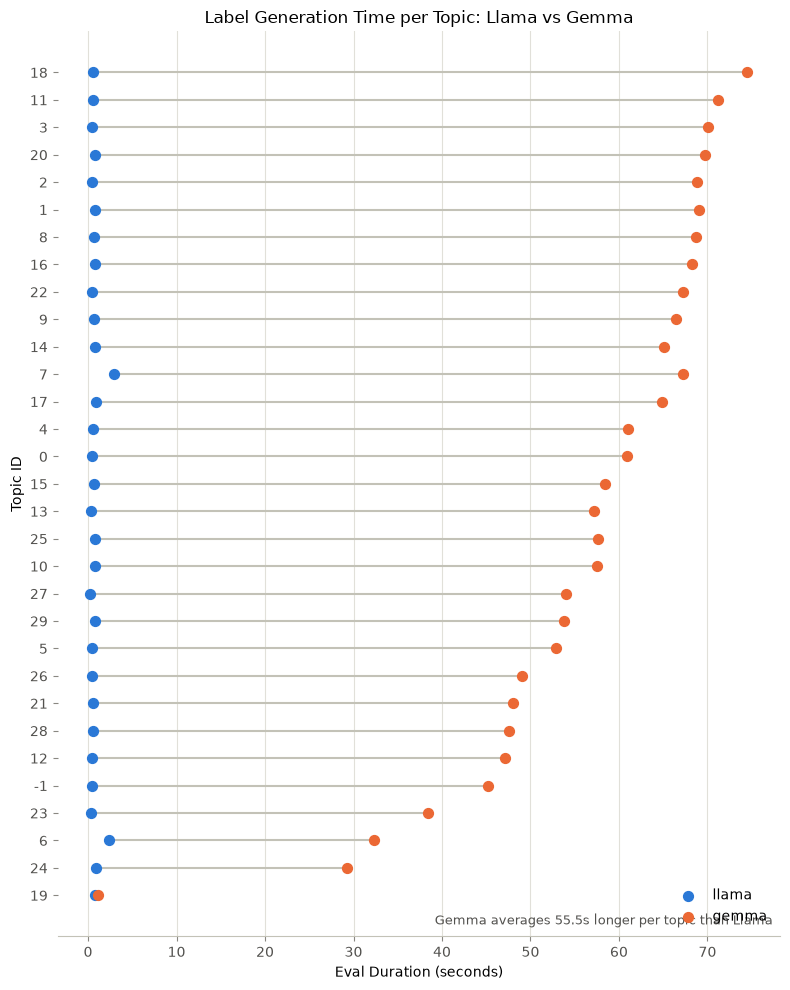

In [ ]:
# reported by Ollama in nanoseconds, so we convert to seconds for readability
import matplotlib.pyplot as plt

durations = pd.merge(
    llama_response_df[["topic_id", "eval_duration"]].rename(columns={"eval_duration": "llama"}),
    gemma_response_df[["topic_id", "eval_duration"]].rename(columns={"eval_duration": "gemma"}),
    on="topic_id",
)
durations["llama"] /= 1e9
durations["gemma"] /= 1e9
durations["gap"] = durations["gemma"] - durations["llama"]
durations = durations.sort_values("gap").reset_index(drop=True)

llama_color = "#2a78d6"
gemma_color = "#eb6834"

fig, ax = plt.subplots(figsize=(8, 10))
y = durations.index

# the connecting line comes first (zorder=1) so the dots draw on top of it
ax.hlines(y, durations["llama"], durations["gemma"], color="#c3c2b7", linewidth=1.5, zorder=1)
ax.scatter(durations["llama"], y, color=llama_color, s=50, label="llama", zorder=2)
ax.scatter(durations["gemma"], y, color=gemma_color, s=50, label="gemma", zorder=2)

ax.set_yticks(y)
ax.set_yticklabels(durations["topic_id"])
ax.set_xlabel("Eval Duration (seconds)")
ax.set_ylabel("Topic ID")
ax.set_title("Label Generation Time per Topic: Llama vs Gemma")
ax.legend(loc="lower right", frameon=False)

ax.grid(axis="x", color="#e1e0d9", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
ax.spines["bottom"].set_color("#c3c2b7")
ax.tick_params(colors="#898781", labelcolor="#52514e")

avg_gap = durations["gap"].mean()
ax.text(
    0.99, 0.01,
    f"Gemma averages {avg_gap:.1f}s longer per topic than Llama",
    transform=ax.transAxes, ha="right", va="bottom", color="#52514e", fontsize=9,
)

plt.tight_layout()
plt.show()